In [1]:
using PyPlot
using JLD2
using Images, ImageFiltering, Rotations, ImageTransformations, CoordinateTransformations
using Statistics

In [23]:
function smooth_imgs(img, size_kernel)
    flat_kernel = ones(size_kernel, size_kernel)/size_kernel^2
    img_smooth = imfilter(img, flat_kernel)
    return img_smooth
end

function normalize(img)
    img_norm = (img .- minimum(img)) ./ (maximum(img)-minimum(img))
    return img_norm
end

function rotate_img_stripe_angle(img)
    """ Finds the angle at which the stripes are along the horizontal axis,
    ie where a sum along the horizontal axis is maximal """
    θ_range = [0:0.1:π/2;]

    Maximum_hor_mean = zeros(length(θ_range))

    for (i, θ) in enumerate(θ_range)
        trfm = recenter(RotMatrix(θ), center(img))
        imgw = warp(img, trfm)
        imgw[isnan.(imgw)] .= 0 # Padd the NaN values to 0

        Maximum_hor_mean[i] = maximum(sum(imgw, dims=2))
    end
    return θ_range[argmax(Maximum_hor_mean)]
end

rotate_img_stripe_angle (generic function with 1 method)

In [3]:
pathdir = "Y:/TwoDGas/2026/02/06/0000"
@load "Saved_exp_data/ODs_crop_"*join(split(pathdir, "/")[3:end], "_")*".jld2" ODs_dataset

# Stripes detection parameters
size_kernel_smooth = 5;

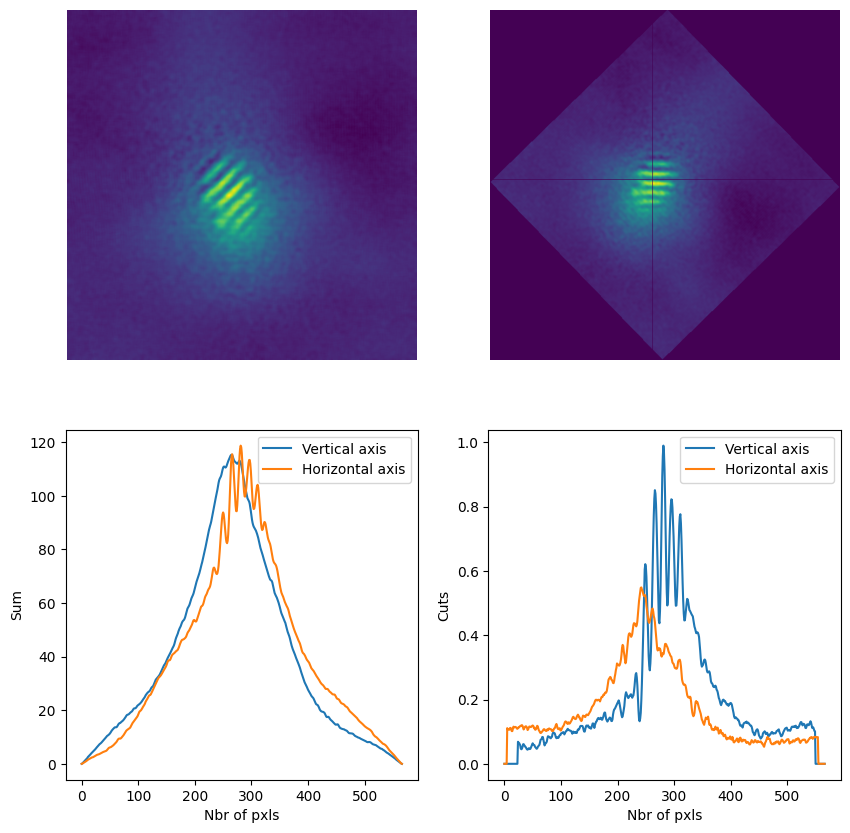

In [24]:
i, j = 19, 10

close("all")
fig, axs = subplots(2, 2, figsize=(10, 10))

OD = ODs_dataset[i, j, :, :]
smooth_norm_OD = normalize(smooth_imgs(OD, size_kernel_smooth)) # Normalize to gaussian kernel

axs[1, 1].imshow(smooth_norm_OD)

# trfm = recenter(RotMatrix(pi/4-0.05+0), center(smooth_norm_OD))
trfm = recenter(RotMatrix(rotate_img_stripe_angle(smooth_norm_OD)), center(smooth_norm_OD))
imgw = warp(smooth_norm_OD, trfm)
imgw[isnan.(imgw)] .= 0 # Padd the NaN values to 0


axs[2, 1].plot(sum(imgw, dims=1)', label="Vertical axis")
axs[2, 1].plot(sum(imgw, dims=2), label="Horizontal axis")
axs[2, 1].set_xlabel("Nbr of pxls")
axs[2, 1].set_ylabel("Sum")
axs[2, 1].legend()

x_cut, y_cut = Int(center(imgw)[2])-20, Int(center(imgw)[1])-8

axs[2, 2].plot(imgw[:, x_cut], label="Vertical axis")
axs[2, 2].plot(imgw[y_cut, :], label="Horizontal axis")
axs[2, 2].set_xlabel("Nbr of pxls")
axs[2, 2].set_ylabel("Cuts")

axs[1, 1].axis("off"), axs[1, 2].axis("off")

imgw[y_cut, :] .= 0
imgw[:, x_cut] .= 0
# imgw[imgw.<0.2] .= 0
axs[1, 2].imshow(imgw)
axs[2, 2].legend()

pygui(false);
# pygui(true); show();